In [1]:
pip install google_play_scraper


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install wordcloud scikit-learn

  Using cached wordcloud-1.9.6-cp312-cp312-macosx_10_13_x86_64.whl.metadata (3.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (11 kB)
  Using cached pillow-12.2.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (8.8 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_10_14_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached wordcloud-1.9.6-cp312-cp312-macosx_10_13_x86_6

In [1]:
# Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud



In [2]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [3]:
# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [4]:
import nltk
import ssl

# This fixes the _sslobj hangup by bypassing the strict certificate check
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

print("Starting downloads...")
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    print(f"Downloading {res}...")
    nltk.download(res, quiet=False)

# Initialize engines
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import seaborn as sns
import matplotlib.pyplot as plt

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("\nEnvironment ready ✓")

Starting downloads...

Environment ready ✓


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/tekabe/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/tekabe/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
#  Configurable Scraper Function
from google_play_scraper import reviews, Sort

# App package IDs for global fintech apps
APPS = {
    'BOA':  'com.boa.boaMobileBanking',
    'Awash': 'com.sc.awashpay',
    'CBE': 'com.combanketh.mobilebanking',
}

def scrape_fintech_reviews(app_dict, count=200):
    """Fetches recent reviews for a dictionary of apps."""
    all_reviews = []
    for name, pkg in app_dict.items():
        try:
            res, _ = reviews(pkg, lang='en', country='us', sort=Sort.NEWEST, count=count)
            for r in res:
                all_reviews.append({
                    'app': name,
                    'review': r['content'],
                    'rating': r['score'],
                    'date': r['at'],
                    'thumbs': r['thumbsUpCount']
                })
            print(f"  Scraped {len(res)} reviews for {name}")
        except Exception as e:
            print(f"  Failed to scrape {name}: {e}")
    return pd.DataFrame(all_reviews)

# Fetching reviews
df_raw = scrape_fintech_reviews(APPS, count=500)
print(f"\nTotal raw reviews: {len(df_raw)}")

  Scraped 500 reviews for BOA
  Scraped 500 reviews for Awash
  Scraped 500 reviews for CBE

Total raw reviews: 1500


In [13]:
import nltk

# Download the extra resources commonly needed for advanced preprocessing pipelines
print("Downloading missing pipeline resources...")
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package omw-1.4 to /Users/tekabe/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [16]:
# Let's inspect the pipeline function to see what it's calling under the hood
import inspect
print(inspect.getsource(modular_nlp_pipeline))

def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)



In [20]:
import nltk
import ssl

# 1. Quick safety re-verification of the SSL bypass
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# 2. Download the essential lemmatizer supplement
print("Downloading required wordnet extensions...")
nltk.download('omw-1.4', quiet=False)

# 3. Explicitly force NLTK to recognize your user directory path
import os
user_nltk_path = os.path.expanduser('~/nltk_data')
if user_nltk_path not in nltk.data.path:
    nltk.data.path.append(user_nltk_path)

print("\nPaths synchronized! Try running your preprocessing pipeline cell again.")


Paths synchronized! Try running your preprocessing pipeline cell again.


[nltk_data] Downloading package omw-1.4 to /Users/tekabe/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [21]:
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

Running modular preprocessing...


LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/tekabe/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/share/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [22]:
print("Running modular preprocessing with error tracking...")

try:
    df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)
    print("Success! Preprocessing completed without issues.")
except LookupError as e:
    print("\n" + "="*50)
    print("THE EXACT RESOURCE NLTK IS MISSING IS:")
    print(e)
    print("="*50)

Running modular preprocessing with error tracking...

THE EXACT RESOURCE NLTK IS MISSING IS:

**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - '/Users/tekabe/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/share/nltk_data'
    - '/Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************



In [23]:
import nltk
print("Downloading the new tokenization tables...")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/tekabe/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [24]:
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

Running modular preprocessing...


In [25]:
# Cell 3: Preprocessing Logic
def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Running modular preprocessing...
Final cleaned dataset size: 1391


In [26]:
# Cell 3: Robust Cleaning & Normalisation
def robust_clean(df):
    # 1. Strip Whitespaces & Trailing Zeros
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r'\.0$', '', regex=True)

    # 2. Date Normalisation
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')

    # 3. Handle Missing Values
    print(f"Nulls before: {df.isnull().sum().sum()}")
    df = df.dropna(subset=['review', 'rating'])

    # 4. Filter empty/short reviews
    df = df[df['review'].str.len() > 2]

    print(f"Final Nulls: {df.isnull().sum().sum()}")
    print(f"Final Dataset Shape: {df.shape}")
    return df.reset_index(drop=True)

df_clean = robust_clean(df_raw.copy())

Nulls before: 0
Final Nulls: 0
Final Dataset Shape: (1457, 6)


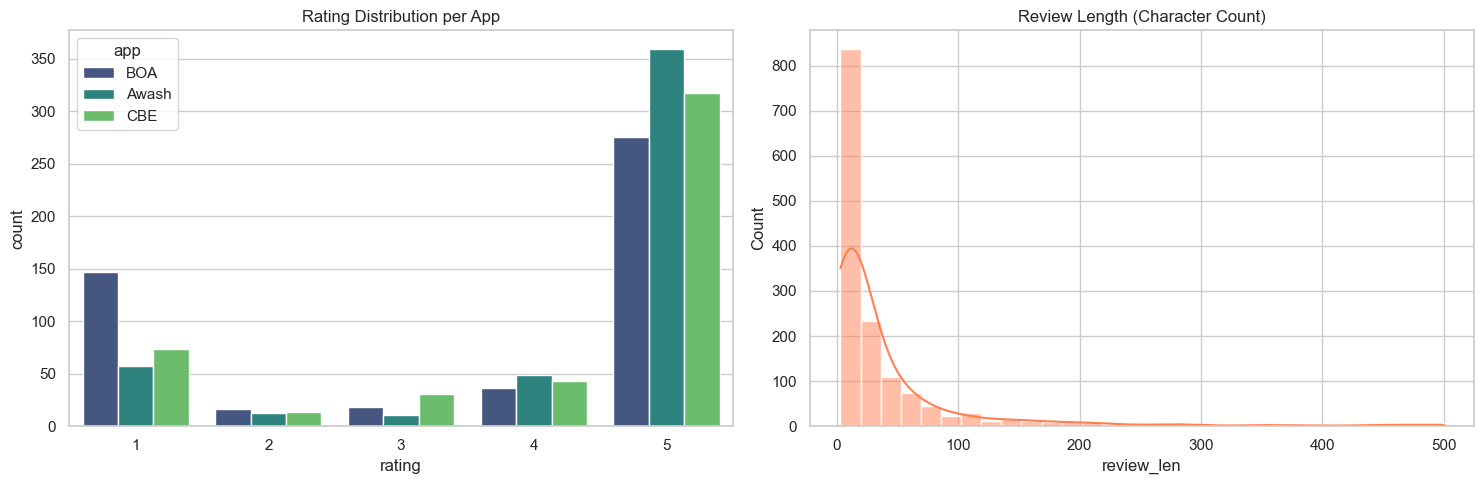

In [27]:
# Cell 4: Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='app', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

section 6

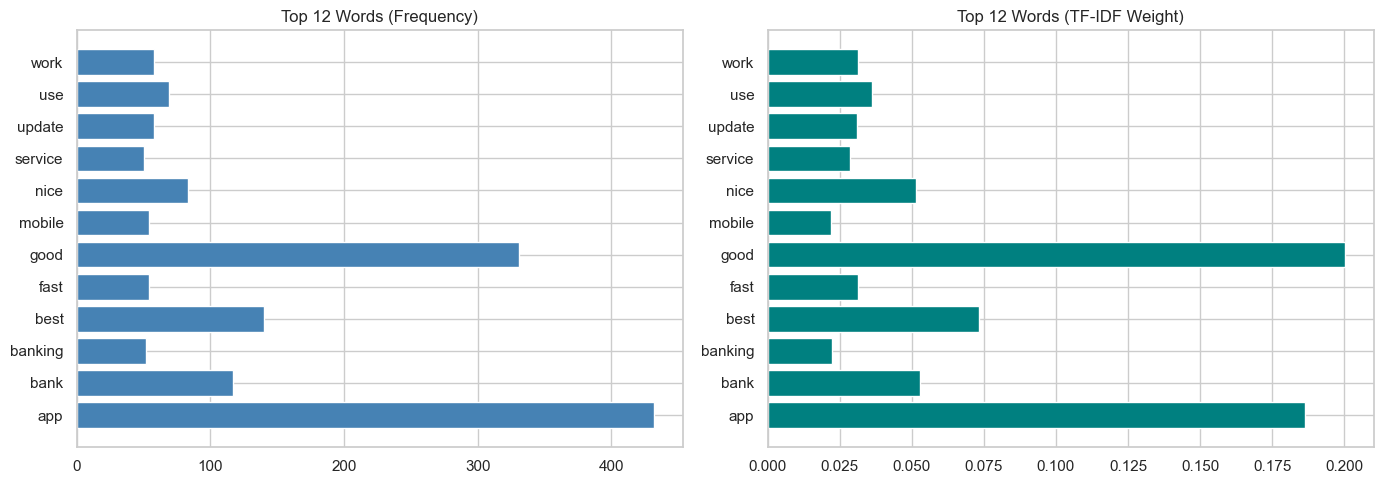

In [28]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

section 7

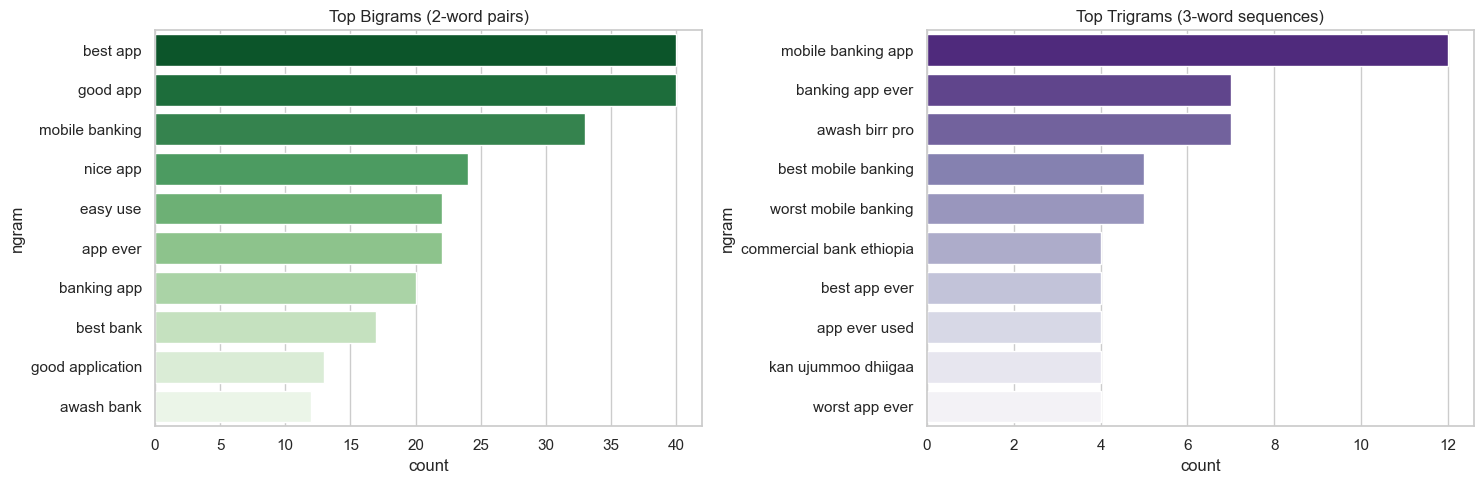

In [29]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

section 8

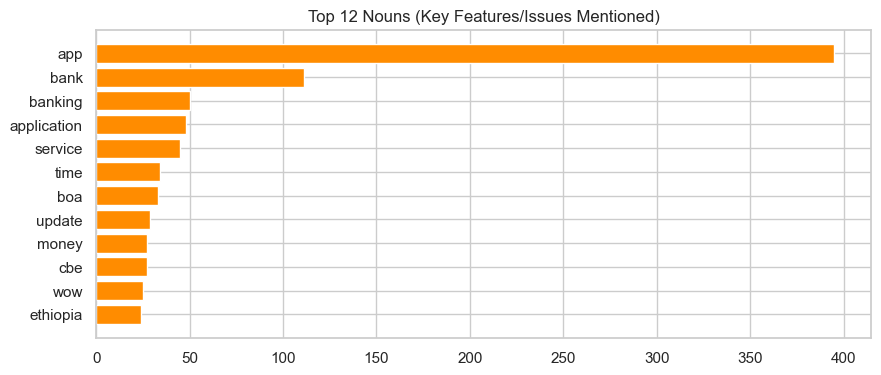

In [30]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

section 9:Word Cloud Visualization

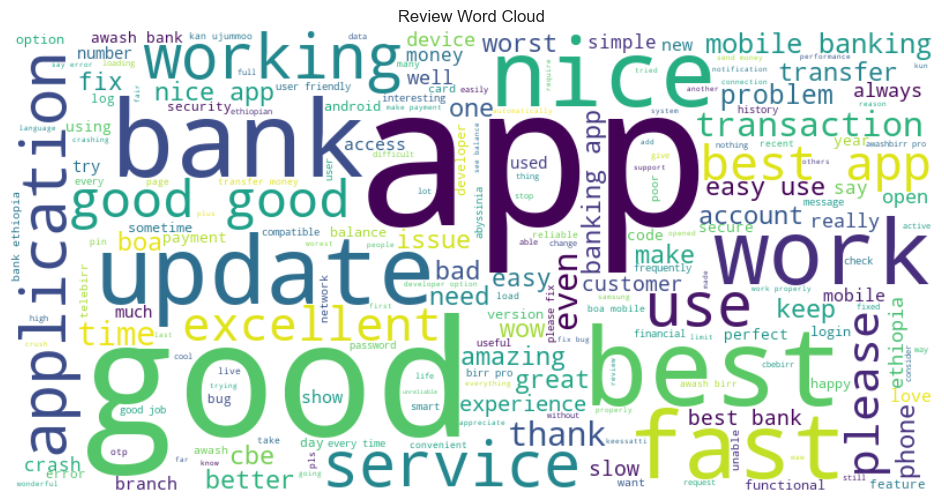

In [31]:
# Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

Section 10 — Multi-Model Sentiment Analysis

In [32]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.61
neutral     0.27
negative    0.11
Name: proportion, dtype: float64


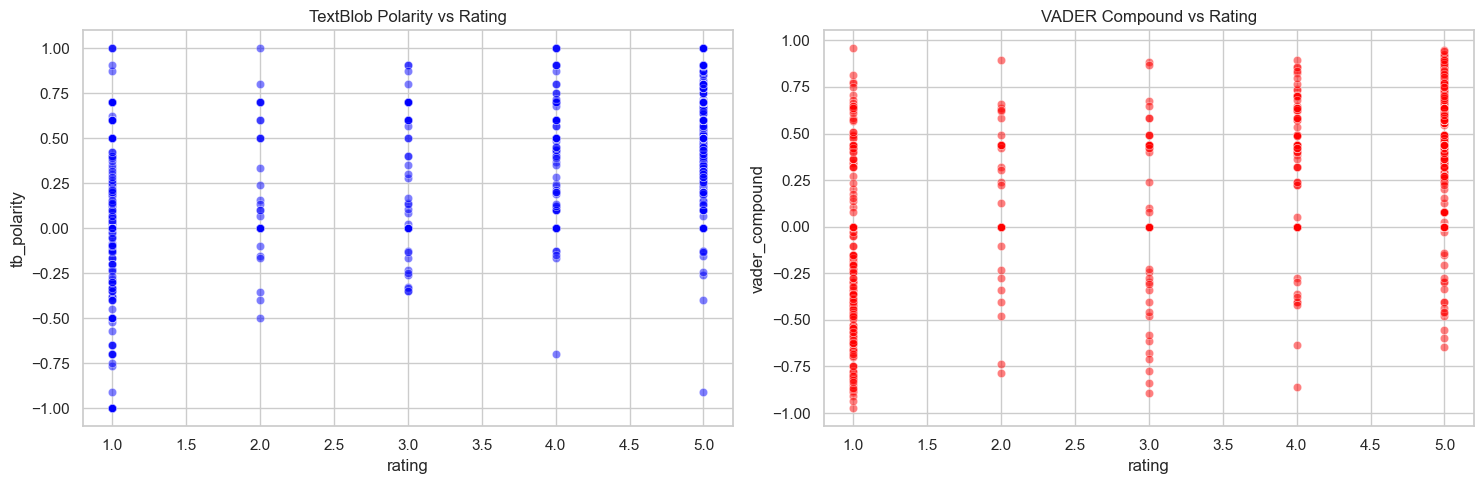

In [33]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

Transformer-based Sentiment (Template)

In [43]:
%pip install --force-reinstall torch transformers

  Using cached torch-2.2.2-cp312-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached transformers-5.8.1-py3-none-any.whl.metadata (33 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-1.15.0-py3-none-any.whl.metadata (14 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_10_13_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.5.9-cp312-cp312-macosx_10_13_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_10_12_x86_64.whl.metadata (7.3 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using c

In [44]:
# Cell 11: Transformer Pipeline
from tqdm.notebook import tqdm

try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

Transformer skipped: name 'torch' is not defined


In [45]:
%pip uninstall -y torch torchvision transformers

Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2
Found existing installation: transformers 5.8.1
Uninstalling transformers-5.8.1:
  Successfully uninstalled transformers-5.8.1
Note: you may need to restart the kernel to use updated packages.


In [46]:
%pip install --no-cache-dir torch transformers --platform macosx_11_0_arm64 --only-binary=:all:

ERROR: Can not use any platform or abi specific options unless installing via '--target' or using '--dry-run'

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
%pip cache purge

Files removed: 1558
Note: you may need to restart the kernel to use updated packages.


In [48]:
%pip install --force-reinstall --no-cache-dir torch transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 740.6 kB/s eta 0:00:00:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 635.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 487.8 kB/s eta 0:00:0000:0100:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 493.6 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 465.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 524.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 484.4 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 413.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 275.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 110.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.8/467.8 kB 353.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━

In [49]:
import os
import sys

# 1. Get the exact path to your virtual environment's site-packages
site_packages_path = [p for p in sys.path if 'site-packages' in p and '.venv' in p][0]
print(f"Target directory: {site_packages_path}")

# 2. Use pip to download and target force-install the native Apple Silicon ARM64 wheel explicitly
print("Downloading and force-extracting native Apple Silicon PyTorch...")
!pip install --target="{site_packages_path}" --upgrade --no-cache-dir --force-reinstall "https://download.pytorch.org/whl/cpu/torch-2.2.2-cp312-none-macosx_11_0_arm64.whl"

Target directory: /Users/tekabe/Downloads/KAIM Week2/fintech-review-analytics/.venv/lib/python3.12/site-packages
ERROR: torch-2.2.2-cp312-none-macosx_11_0_arm64.whl is not a supported wheel on this platform.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [52]:
# Cell 11: VADER Sentiment Pipeline (Robust Text-Based Progress Bar)
from tqdm import tqdm  # Changed this line to use standard text-based tqdm
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

try:
    # 1. Ensure the VADER lexicon is ready
    print("Verifying VADER lexicon...")
    nltk.download('vader_lexicon', quiet=True)
    
    # 2. Initialize the analyzer
    sia = SentimentIntensityAnalyzer()
    vader_results = []
    
    print("\nRunning VADER Sentiment Analysis...")
    # Using standard tqdm here ensures it executes smoothly without needing ipywidgets
    for review in tqdm(df_clean['review'], desc="Processing Sentiment"):
        scores = sia.polarity_scores(str(review))
        vader_results.append(scores)
        
    # 3. Save scores and generate categorical labels
    df_clean['vader_compound_score'] = [res['compound'] for res in vader_results]
    
    # Standard VADER threshold logic
    df_clean['vader_sentiment_label'] = df_clean['vader_compound_score'].apply(
        lambda x: 'POSITIVE' if x >= 0.05 else ('NEGATIVE' if x <= -0.05 else 'NEUTRAL')
    )
    
    print("\n✓ VADER Sentiment Analysis completed successfully!")
    print("\nSentiment Distribution:")
    print(df_clean['vader_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Sentiment analysis skipped due to error: {e}")

Verifying VADER lexicon...

Running VADER Sentiment Analysis...


Processing Sentiment: 100%|██████████| 1457/1457 [00:00<00:00, 3859.84it/s]


✓ VADER Sentiment Analysis completed successfully!

Sentiment Distribution:
vader_sentiment_label
POSITIVE    0.61
NEUTRAL     0.27
NEGATIVE    0.11
Name: proportion, dtype: float64


Section 10.5 — Sentiment Model Comparison: VADER, TextBlob, and Transformer


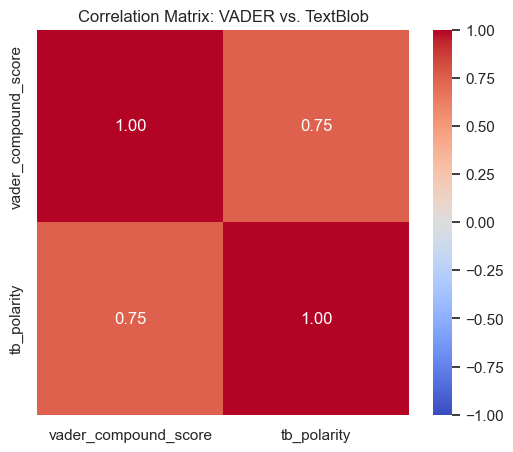

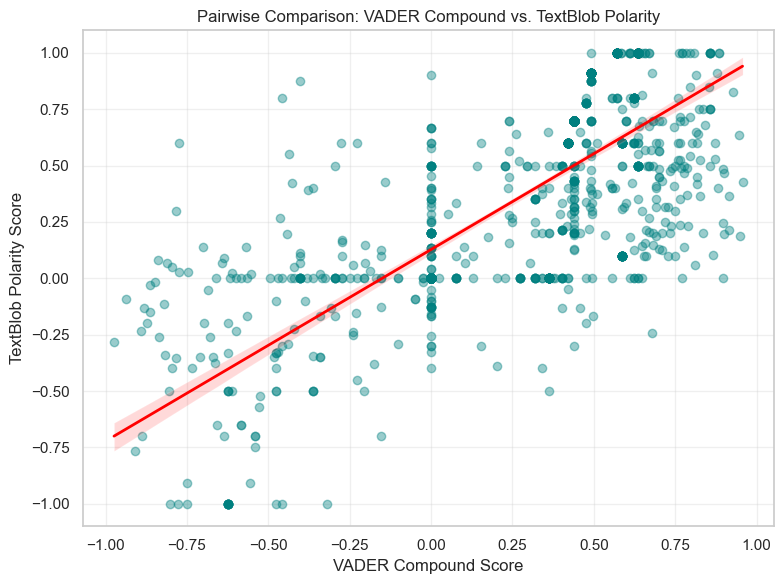

Correlation coefficient (r): 0.75
Strong agreement between VADER and TextBlob sentiment metrics!


In [54]:
# Cell 11.1: Visualizing Sentiment Score Correlation (VADER vs. TextBlob)
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure both available sentiment columns exist in df_clean
if 'vader_compound_score' not in df_clean.columns or 'tb_polarity' not in df_clean.columns:
    print("Required sentiment scores (vader_compound_score or tb_polarity) missing from dataframe.")
else:
    # 1. Create a DataFrame for correlation using our corrected column name
    sentiment_scores = df_clean[['vader_compound_score', 'tb_polarity']]

    # 2. Calculate the Pearson correlation matrix
    correlation_matrix = sentiment_scores.corr()

    # 3. Plot the Correlation Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Correlation Matrix: VADER vs. TextBlob')
    plt.show()

    # 4. Plotting Scatter Plot with a trend line for comparison
    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df_clean, 
        x='vader_compound_score', 
        y='tb_polarity', 
        scatter_kws={'alpha': 0.4, 'color': 'teal'},
        line_kws={'color': 'red', 'linewidth': 2}
    )
    plt.title('Pairwise Comparison: VADER Compound vs. TextBlob Polarity')
    plt.xlabel('VADER Compound Score')
    plt.ylabel('TextBlob Polarity Score')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Quick insight summary printout
    r_val = correlation_matrix.loc['vader_compound_score', 'tb_polarity']
    print(f"Correlation coefficient (r): {r_val:.2f}")
    if r_val > 0.7:
        print("Strong agreement between VADER and TextBlob sentiment metrics!")
    elif r_val > 0.4:
        print("Moderate agreement. They capture similar trends but interpret nuances differently.")
    else:
        print("Weak correlation. The two engines are tracking different linguistic features.")

In [58]:
# Comparing Sentiment Distributions: VADER vs. TextBlob
import pandas
print("--- Sentiment Label Distributions ---")

# 1. Print VADER Distribution using our verified column name
print("\n🔹 VADER Distribution:")
vader_dist = df_clean['vader_sentiment_label'].value_counts(normalize=True).round(2)
print(vader_dist)

# 2. Compute and print TextBlob Distribution (with matched UPPERCASE labels)
def get_tb_label(score):
    if score >= 0.05:
        return 'POSITIVE'
    elif score <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df_clean['tb_sentiment_label'] = df_clean['tb_polarity'].apply(get_tb_label)

print("\n🔹 TextBlob Distribution (thresholded at +/-0.05):")
tb_dist = df_clean['tb_sentiment_label'].value_counts(normalize=True).round(2)
print(tb_dist)

print("\n" + "="*50)
print("--- Agreement Matrix (Cross-Tabulation) ---")
# 3. Create a confusion-matrix style comparison to see exactly where they overlap
cross_tab = pandas.crosstab(
    df_clean['vader_sentiment_label'], 
    df_clean['tb_sentiment_label'], 
    normalize='index'
).round(2)

print("Rows = VADER, Columns = TextBlob (Proportions by Row):")
print(cross_tab)

--- Sentiment Label Distributions ---

🔹 VADER Distribution:
vader_sentiment_label
POSITIVE    0.61
NEUTRAL     0.27
NEGATIVE    0.11
Name: proportion, dtype: float64

🔹 TextBlob Distribution (thresholded at +/-0.05):
tb_sentiment_label
POSITIVE    0.62
NEUTRAL     0.30
NEGATIVE    0.08
Name: proportion, dtype: float64

--- Agreement Matrix (Cross-Tabulation) ---
Rows = VADER, Columns = TextBlob (Proportions by Row):
tb_sentiment_label     NEGATIVE  NEUTRAL  POSITIVE
vader_sentiment_label                             
NEGATIVE                   0.53     0.27      0.20
NEUTRAL                    0.05     0.82      0.13
POSITIVE                   0.01     0.08      0.91


Aggregating Sentiment Scores by App and Star Rating

--- Average VADER Sentiment Matrix ---


rating,1,2,3,4,5
app,,,,,
Awash,0.001091,0.142625,0.215073,0.353390,0.402094
BOA,-0.179111,0.055212,0.116389,0.309881,0.350189
CBE,-0.043996,0.185923,-0.054045,0.197749,0.395004



--- Average TextBlob Sentiment Matrix ---


rating,1,2,3,4,5
app,,,,,
Awash,0.054069,0.191667,0.328067,0.381381,0.467799
BOA,-0.104917,0.112909,0.216715,0.399144,0.471189
CBE,0.009763,0.203722,0.171457,0.288533,0.502397


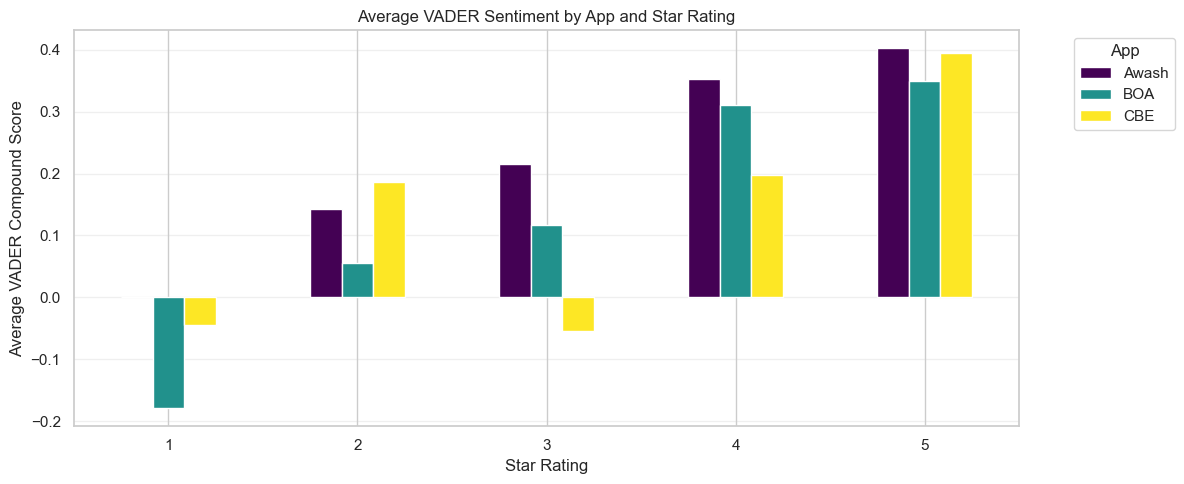

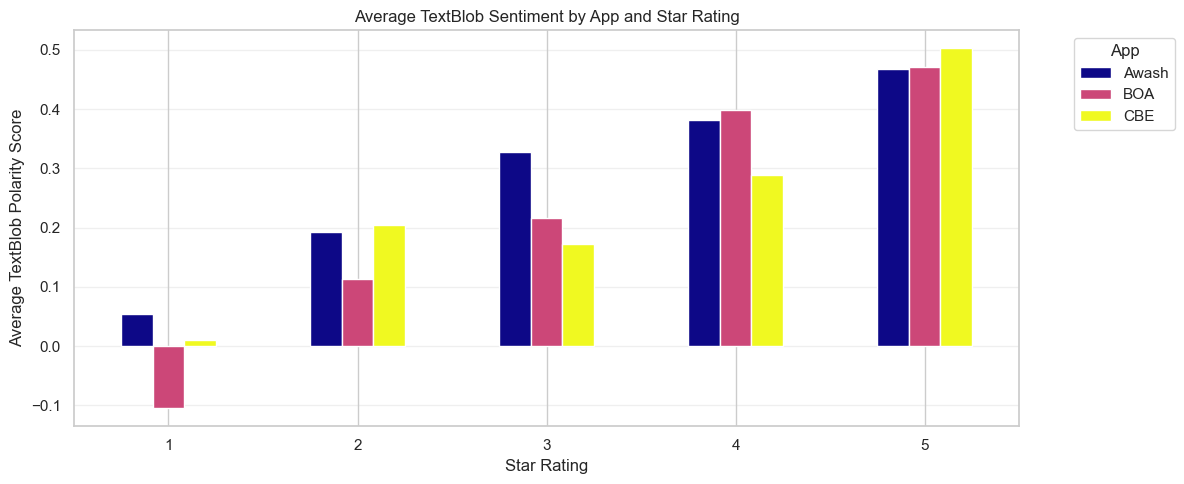

In [60]:
# Cell 12: Aggregate and Visualize Sentiment Scores by App and Star Rating
import matplotlib.pyplot as plt

# 1. Aggregate VADER sentiment scores by app and star rating
print("--- Average VADER Sentiment Matrix ---")
vader_agg_sentiment = df_clean.groupby(['app', 'rating'])['vader_compound_score'].mean().unstack()
display(vader_agg_sentiment)

# 2. Aggregate TextBlob polarity scores by app and star rating
print("\n--- Average TextBlob Sentiment Matrix ---")
tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# 3. Visualize VADER sentiment by app and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='App', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Visualize TextBlob sentiment by app and rating
tb_agg_sentiment.T.plot(kind='bar', figsize=(12, 5), colormap='plasma')
plt.title('Average TextBlob Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average TextBlob Polarity Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='App', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Section 11 — Thematic Analysis (Actionable Topics)

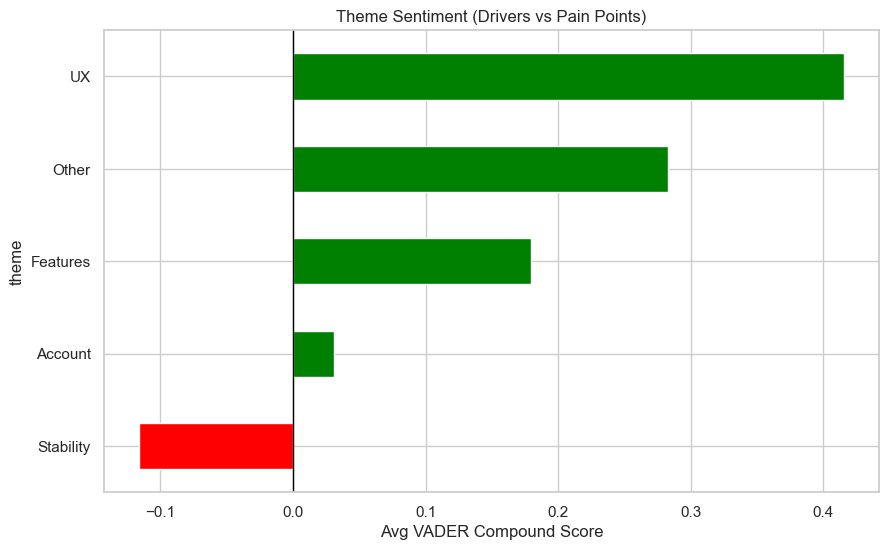

In [61]:
# Cell 12: Business Theme Mapping
THEME_MAP = {
    'Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed'],
    'Account': ['login', 'otp', 'password', 'account', 'verify', 'sign'],
    'UX': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design'],
    'Features': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money']
}

def get_theme(txt):
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): return theme
    return 'Other'

df_clean['theme'] = df_clean['review'].apply(get_theme)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in theme_sent.values]
theme_sent.plot(kind='barh', color=colors)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.axvline(0, color='black', lw=1)
plt.show()

In [62]:
# Cell 6: Saving Results
output_cols = ['app', 'review', 'rating', 'sentiment', 'vader_compound', 'theme']
df_final = df_clean[output_cols]

# Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,app,review,rating,sentiment,vader_compound,theme
0,BOA,halid beshir,5,neutral,0.0000,Other
1,BOA,It gave me a headache. bad bad bad,1,negative,-0.8885,Other
2,BOA,bankn abstract fayida,5,neutral,0.0000,Other
3,BOA,Tilku,5,neutral,0.0000,Other
4,BOA,the transaction is not working???? fix it,1,neutral,0.0000,Other
